In [2]:
import sys
print(sys.executable)

C:\Users\duyif\miniconda3\envs\pytorch_new\python.exe


In [3]:
from pathlib import Path
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt

data_dir = Path(r"D:\biosignal-data\WAY-EEG-GAL\P1")
hs = loadmat(
    data_dir / "HS_P1_S1.mat",
    struct_as_record=False,
    squeeze_me=True
)["hs"]

print("受试者：", hs.participant, "记录序号：", hs.series)
print("EEG：", hs.eeg.sig.shape, "采样率：", hs.eeg.samplingrate)
print("运动学：", hs.kin.sig.shape, "采样率：", hs.kin.samplingrate)

受试者： 1 记录序号： 1
EEG： (119496, 32) 采样率： 500
运动学： (119496, 36) 采样率： 500


In [4]:
eeg_names = list(hs.eeg.names)
kin_names = list(hs.kin.names)

print("EEG 通道：", eeg_names)
print("C3 的列号：", eeg_names.index("C3"))

for name in ("Px4", "Py4", "Pz4"):
    matches = [(i, n) for i, n in enumerate(kin_names) if str(n).startswith(name + " ")]
    print(name, matches)

EEG 通道： ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6', 'T7', 'C3', 'Cz', 'C4', 'T8', 'TP9', 'CP5', 'CP1', 'CP2', 'CP6', 'TP10', 'P7', 'P3', 'Pz', 'P4', 'P8', 'PO9', 'O1', 'Oz', 'O2', 'PO10']
C3 的列号： 12
Px4 [(21, 'Px4 - position x sensor 4')]
Py4 [(25, 'Py4 - position y sensor 4')]
Pz4 [(29, 'Pz4 - position z sensor 4')]


In [5]:
from matplotlib import font_manager

font_path = r"C:\Windows\Fonts\msyh.ttc"  # Windows 的微软雅黑
font_manager.fontManager.addfont(font_path)
plt.rcParams["font.family"] = font_manager.FontProperties(
    fname=font_path
).get_name()
plt.rcParams["axes.unicode_minus"] = False

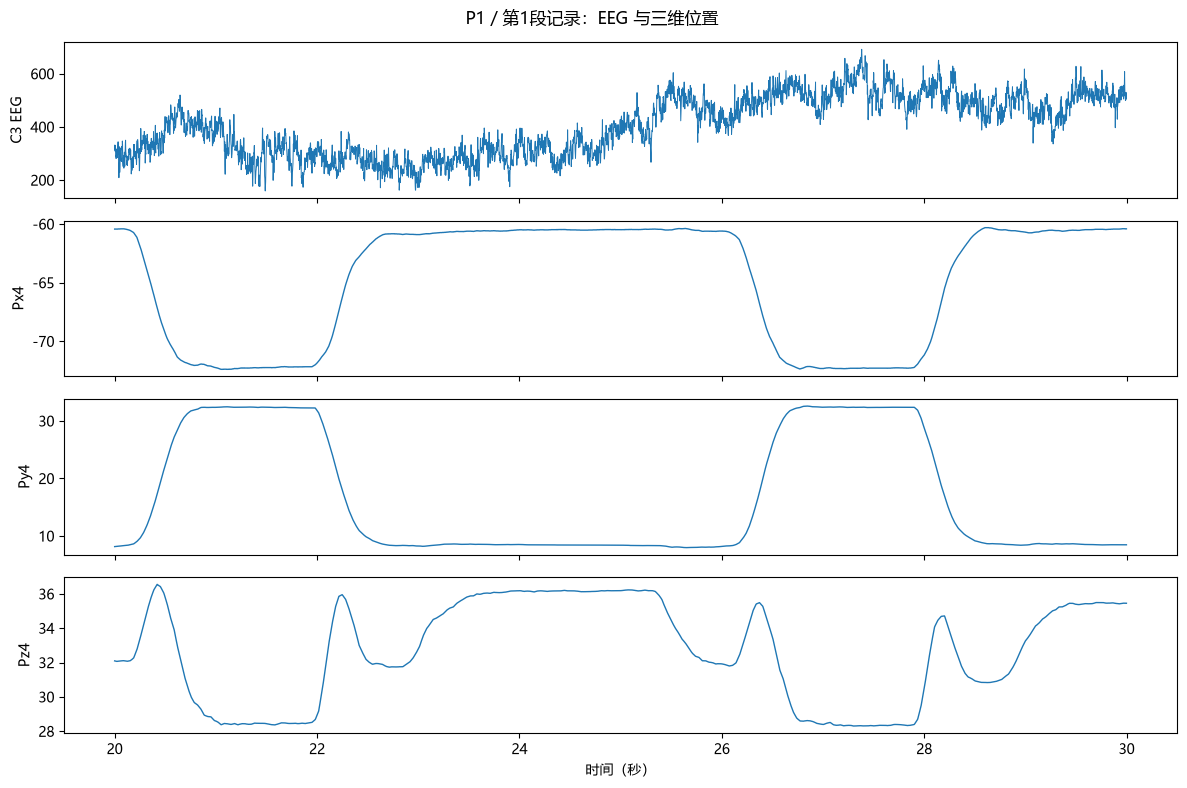

In [6]:
fs = int(hs.eeg.samplingrate)
start, stop = 20 * fs, 30 * fs
time = np.arange(start, stop) / fs

c3 = eeg_names.index("C3")
position_cols = [
    next(i for i, n in enumerate(kin_names) if str(n).startswith(name + " "))
    for name in ("Px4", "Py4", "Pz4")
]

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

axes[0].plot(time, hs.eeg.sig[start:stop, c3], linewidth=0.7)
axes[0].set_ylabel("C3 EEG")

for ax, col, name in zip(axes[1:], position_cols, ("Px4", "Py4", "Pz4")):
    ax.plot(time, hs.kin.sig[start:stop, col], linewidth=1)
    ax.set_ylabel(name)

axes[-1].set_xlabel("时间（秒）")
fig.suptitle("P1 / 第1段记录：EEG 与三维位置")
plt.tight_layout()
plt.show()

试次起点（在整段记录中的秒数）： 21.572000000000003
LEDOn ： 2.0 秒（相对试次起点）
tHandStart ： 2.39 秒（相对试次起点）
tLiftOff ： 3.2840000000000003 秒（相对试次起点）
LEDOff ： 5.515999999999998 秒（相对试次起点）
tReplace ： 6.256 秒（相对试次起点）


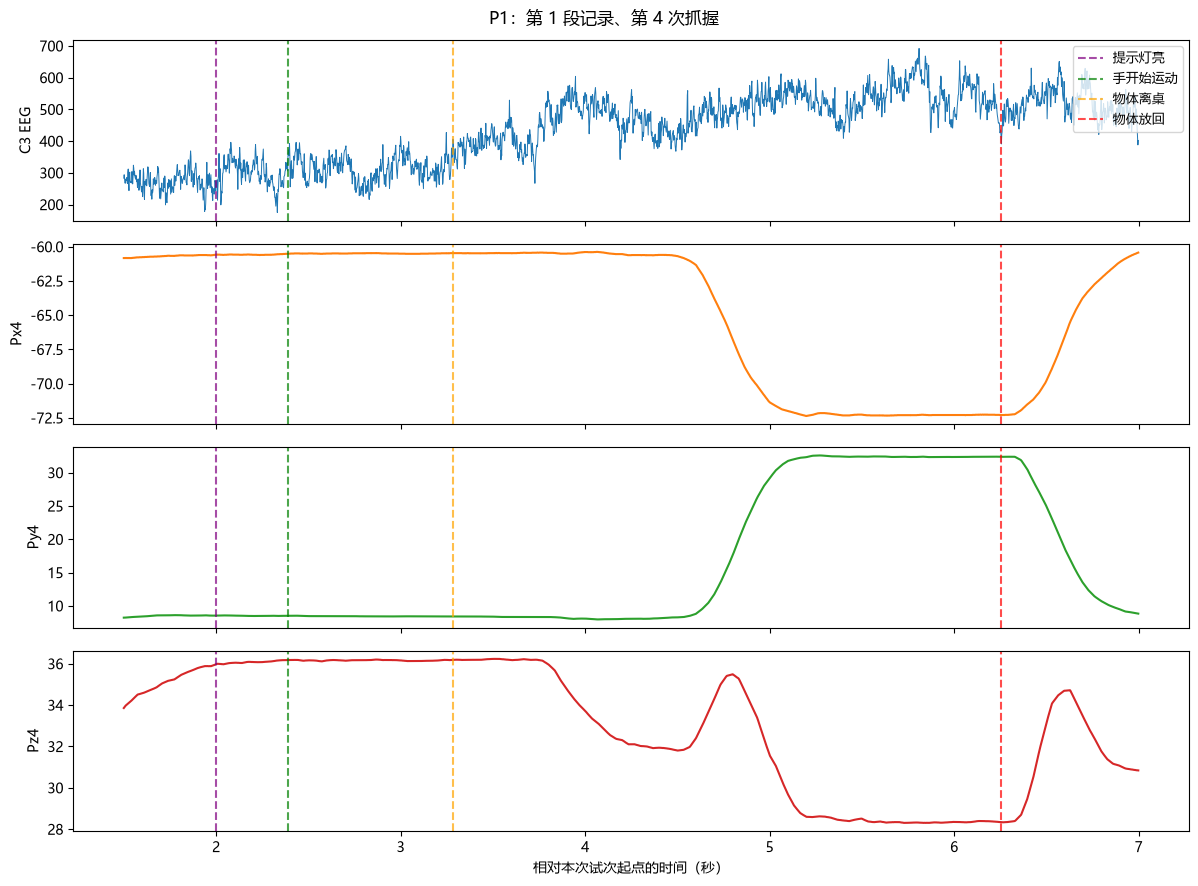

In [7]:
# 读取每次抓握的时间标记
P = loadmat(
    data_dir / "P1_AllLifts.mat",
    struct_as_record=False,
    squeeze_me=True
)["P"]

columns = list(P.ColNames)
run_col = columns.index("Run")
lift_col = columns.index("Lift")

# 选择第 1 段记录中的第 4 次抓握
rows = P.AllLifts[
    (P.AllLifts[:, run_col] == 1) &
    (P.AllLifts[:, lift_col] == 4)
]
trial = dict(zip(columns, rows[0]))

print("试次起点（在整段记录中的秒数）：", trial["StartTime"])
for name in ("LEDOn", "tHandStart", "tLiftOff", "LEDOff", "tReplace"):
    print(name, "：", trial[name], "秒（相对试次起点）")

# 截取这一次试验；横轴改为“距离本次试次起点的时间”
trial_start = trial["StartTime"]
i0 = round((trial_start + 1.5) * fs)
i1 = round((trial_start + 7.0) * fs)
t = np.arange(i0, i1) / fs - trial_start

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)

axes[0].plot(t, hs.eeg.sig[i0:i1, c3], color="tab:blue", linewidth=0.7)
axes[0].set_ylabel("C3 EEG")

for ax, col, name, color in zip(
    axes[1:], position_cols, ("Px4", "Py4", "Pz4"),
    ("tab:orange", "tab:green", "tab:red")
):
    ax.plot(t, hs.kin.sig[i0:i1, col], color=color)
    ax.set_ylabel(name)

events = {
    "提示灯亮": ("LEDOn", "purple"),
    "手开始运动": ("tHandStart", "green"),
    "物体离桌": ("tLiftOff", "orange"),
    "物体放回": ("tReplace", "red"),
}
for label, (field, color) in events.items():
    event_time = trial[field]
    if np.isfinite(event_time):
        for ax in axes:
            ax.axvline(event_time, color=color, linestyle="--",
                       alpha=0.7, label=label if ax is axes[0] else None)

axes[0].legend(loc="upper right", fontsize=9)
axes[-1].set_xlabel("相对本次试次起点的时间（秒）")
fig.suptitle("P1：第 1 段记录、第 4 次抓握")
plt.tight_layout()
plt.show()

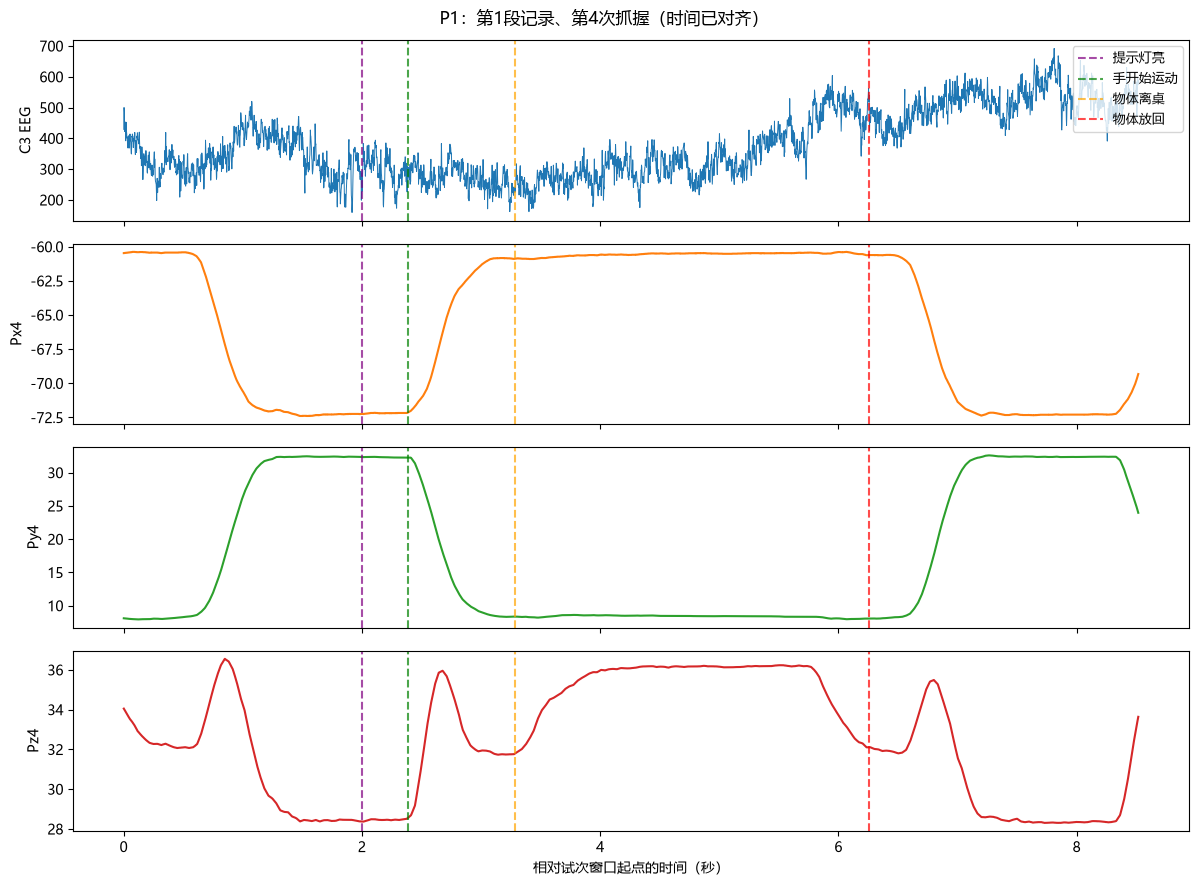

In [8]:
# 第1段记录中的第4次抓握：直接读取已经切好的试次窗口
ws = loadmat(
    data_dir / "WS_P1_S1.mat",
    struct_as_record=False,
    squeeze_me=True
)["ws"]
win = ws.win[3]  # Python 从0计数，所以第4次是索引3
t = np.asarray(win.eeg_t)

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)

axes[0].plot(t, win.eeg[:, c3], color="tab:blue", linewidth=0.7)
axes[0].set_ylabel("C3 EEG")

for ax, col, name, color in zip(
    axes[1:], position_cols, ("Px4", "Py4", "Pz4"),
    ("tab:orange", "tab:green", "tab:red")
):
    ax.plot(t, win.kin[:, col], color=color)
    ax.set_ylabel(name)

events = {
    "提示灯亮": ("LEDOn", "purple"),
    "手开始运动": ("tHandStart", "green"),
    "物体离桌": ("tLiftOff", "orange"),
    "物体放回": ("tReplace", "red"),
}
for label, (field, color) in events.items():
    event_time = trial[field]
    if np.isfinite(event_time):
        for ax in axes:
            ax.axvline(
                event_time, color=color, linestyle="--", alpha=0.7,
                label=label if ax is axes[0] else None
            )

axes[0].legend(loc="upper right", fontsize=9)
axes[-1].set_xlabel("相对试次窗口起点的时间（秒）")
fig.suptitle("P1：第1段记录、第4次抓握（时间已对齐）")
plt.tight_layout()
plt.show()

EEG 输入 X： (150, 32)
手腕轨迹 Y： (500, 3)


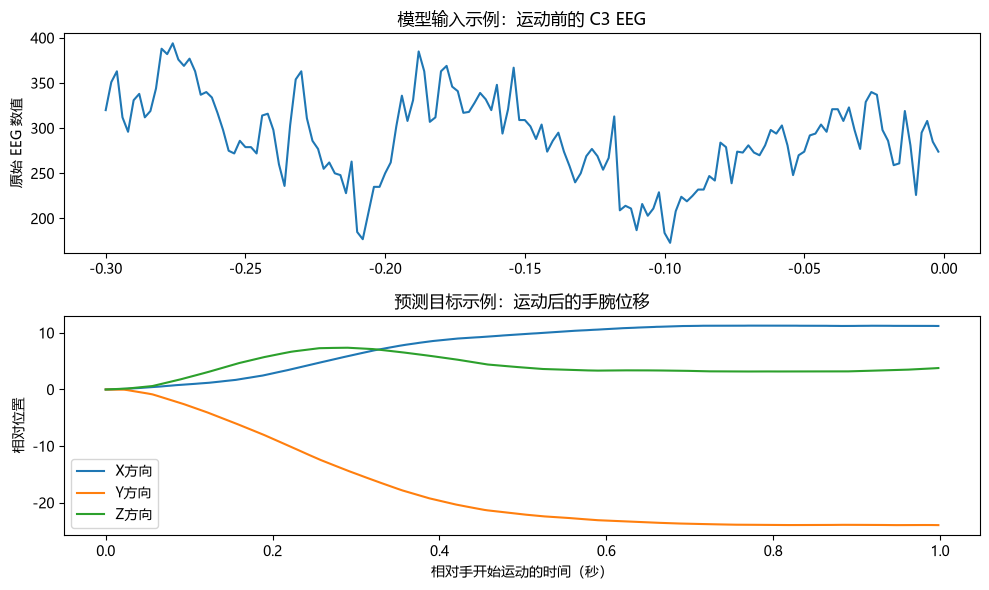

In [9]:
# 示例窗口：运动前 0.3 秒 EEG，预测运动后 1.0 秒手腕轨迹
# 这是入门检查用的窗口长度，还不是论文最终参数
onset = float(trial["tHandStart"])
onset_idx = np.searchsorted(win.eeg_t, onset)

n_before = round(0.3 * fs)  # 150 个采样点
n_after = round(1.0 * fs)   # 500 个采样点

X = win.eeg[onset_idx - n_before:onset_idx, :]          # EEG：时间 × 32通道
Y = win.kin[onset_idx:onset_idx + n_after, position_cols]  # 手腕：时间 × 3坐标
Y_relative = Y - Y[0]  # 相对于运动开始位置的位移，便于看轨迹

print("EEG 输入 X：", X.shape)
print("手腕轨迹 Y：", Y.shape)

t_in = win.eeg_t[onset_idx - n_before:onset_idx] - onset
t_out = win.eeg_t[onset_idx:onset_idx + n_after] - onset

fig, axes = plt.subplots(2, 1, figsize=(10, 6))
axes[0].plot(t_in, X[:, c3])
axes[0].set_title("模型输入示例：运动前的 C3 EEG")
axes[0].set_ylabel("原始 EEG 数值")

axes[1].plot(t_out, Y_relative)
axes[1].set_title("预测目标示例：运动后的手腕位移")
axes[1].set_xlabel("相对手开始运动的时间（秒）")
axes[1].set_ylabel("相对位置")
axes[1].legend(["X方向", "Y方向", "Z方向"])
plt.tight_layout()
plt.show()

In [10]:
X_list, Y_list, kept_lifts = [], [], []

run1_rows = P.AllLifts[P.AllLifts[:, run_col] == 1]

for row in run1_rows:
    lift_number = int(row[lift_col])
    current_win = ws.win[lift_number - 1]
    onset = row[columns.index("tHandStart")]

    if not np.isfinite(onset):
        continue

    idx = np.searchsorted(current_win.eeg_t, onset)
    if idx < n_before or idx + n_after > len(current_win.eeg_t):
        continue

    eeg_part = current_win.eeg[idx - n_before:idx, :]
    wrist_part = current_win.kin[idx:idx + n_after, position_cols]
    wrist_part = wrist_part - wrist_part[0]

    if not np.isfinite(eeg_part).all() or not np.isfinite(wrist_part).all():
        continue

    X_list.append(eeg_part)
    Y_list.append(wrist_part)
    kept_lifts.append(lift_number)

X_batch = np.stack(X_list)
Y_batch = np.stack(Y_list)

print("保留的试次：", len(kept_lifts))
print("EEG 数据形状：", X_batch.shape)
print("真实手腕轨迹形状：", Y_batch.shape)

保留的试次： 34
EEG 数据形状： (34, 150, 32)
真实手腕轨迹形状： (34, 500, 3)


EEG 是否全为有限数值： True
轨迹是否全为有限数值： True
EEG 数值范围： -5108.0 到 9678.0


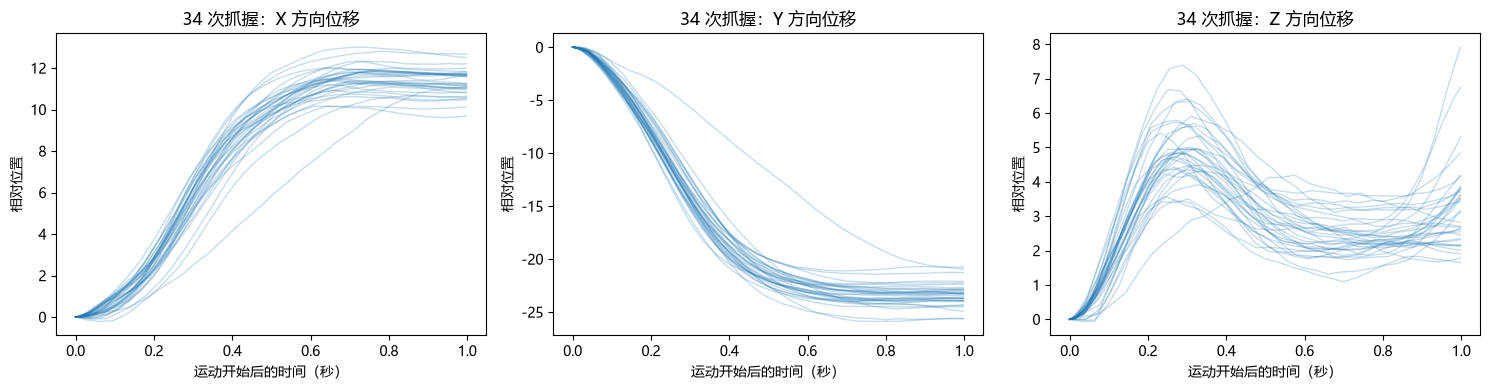

In [11]:
print("EEG 是否全为有限数值：", np.isfinite(X_batch).all())
print("轨迹是否全为有限数值：", np.isfinite(Y_batch).all())
print("EEG 数值范围：", X_batch.min(), "到", X_batch.max())

time_after = np.arange(Y_batch.shape[1]) / fs
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for j, name in enumerate(("X", "Y", "Z")):
    axes[j].plot(time_after, Y_batch[:, :, j].T,
                 color="tab:blue", alpha=0.25, linewidth=1)
    axes[j].set_title(f"34 次抓握：{name} 方向位移")
    axes[j].set_xlabel("运动开始后的时间（秒）")
    axes[j].set_ylabel("相对位置")

plt.tight_layout()
plt.show()

第4次抓握，C3通道前10个EEG数值：
[320. 351. 363. 312. 296. 331. 338. 312. 319. 344.]


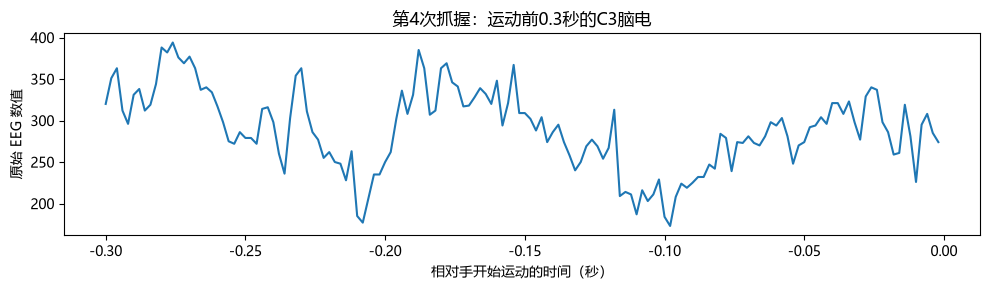

In [12]:
i = 3  # 第4次抓握；Python 从0计数
print("第4次抓握，C3通道前10个EEG数值：")
print(X_batch[i, :10, c3])

t_before = np.arange(X_batch.shape[1]) / fs - 0.3
plt.figure(figsize=(10, 3))
plt.plot(t_before, X_batch[i, :, c3])
plt.xlabel("相对手开始运动的时间（秒）")
plt.ylabel("原始 EEG 数值")
plt.title("第4次抓握：运动前0.3秒的C3脑电")
plt.tight_layout()
plt.show()

第23次抓握 | 通道 T8 | 数值 9678 | 距运动开始 -0.178 秒
第24次抓握 | 通道 T8 | 数值 -5108 | 距运动开始 -0.036 秒
第25次抓握 | 通道 T8 | 数值 -3059 | 距运动开始 -0.296 秒
第14次抓握 | 通道 F8 | 数值 -1946 | 距运动开始 -0.162 秒
第26次抓握 | 通道 TP9 | 数值 -1486 | 距运动开始 -0.158 秒


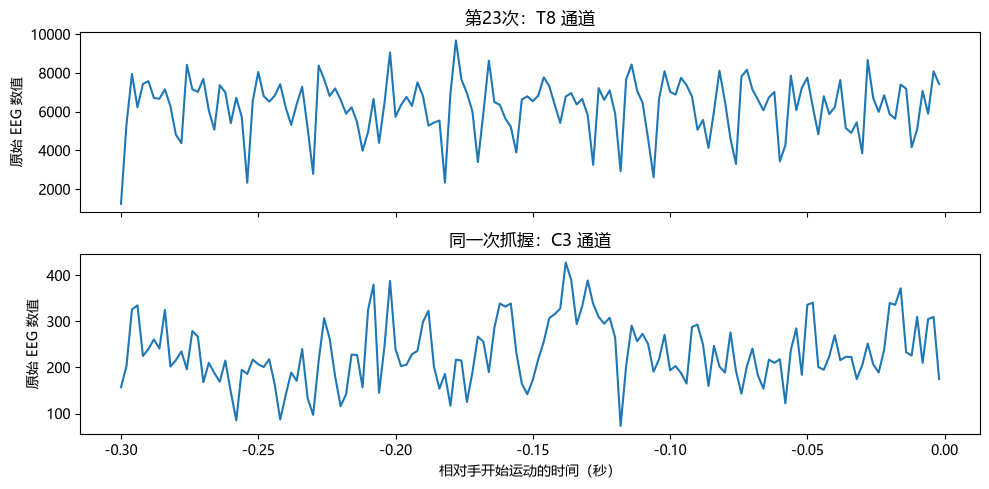

In [13]:
# 找出每次抓握中绝对值最大的 EEG 采样点
peak_per_trial = np.max(np.abs(X_batch), axis=(1, 2))
top_indices = np.argsort(peak_per_trial)[::-1][:5]

for i in top_indices:
    time_idx, channel_idx = np.unravel_index(
        np.argmax(np.abs(X_batch[i])), X_batch[i].shape
    )
    print(
        f"第{kept_lifts[i]}次抓握 | "
        f"通道 {eeg_names[channel_idx]} | "
        f"数值 {X_batch[i, time_idx, channel_idx]:.0f} | "
        f"距运动开始 {(time_idx - n_before) / fs:.3f} 秒"
    )

# 把异常最大的通道与 C3 放在一起查看
i = int(top_indices[0])
_, channel_idx = np.unravel_index(
    np.argmax(np.abs(X_batch[i])), X_batch[i].shape
)
t = np.arange(n_before) / fs - n_before / fs

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(t, X_batch[i, :, channel_idx])
axes[0].set_title(f"第{kept_lifts[i]}次：{eeg_names[channel_idx]} 通道")
axes[0].set_ylabel("原始 EEG 数值")

axes[1].plot(t, X_batch[i, :, c3])
axes[1].set_title("同一次抓握：C3 通道")
axes[1].set_xlabel("相对手开始运动的时间（秒）")
axes[1].set_ylabel("原始 EEG 数值")
plt.tight_layout()
plt.show()

In [14]:
trial_idx, time_idx, channel_idx = np.unravel_index(
    np.argmin(X_batch), X_batch.shape
)

print("数值：", X_batch[trial_idx, time_idx, channel_idx])
print("抓握次数：", kept_lifts[trial_idx])
print("通道：", eeg_names[channel_idx])
print("距运动开始：", (time_idx - n_before) / fs, "秒")
print("数组索引：", trial_idx, time_idx, channel_idx)

数值： -5108.0
抓握次数： 24
通道： T8
距运动开始： -0.036 秒
数组索引： 23 132 15


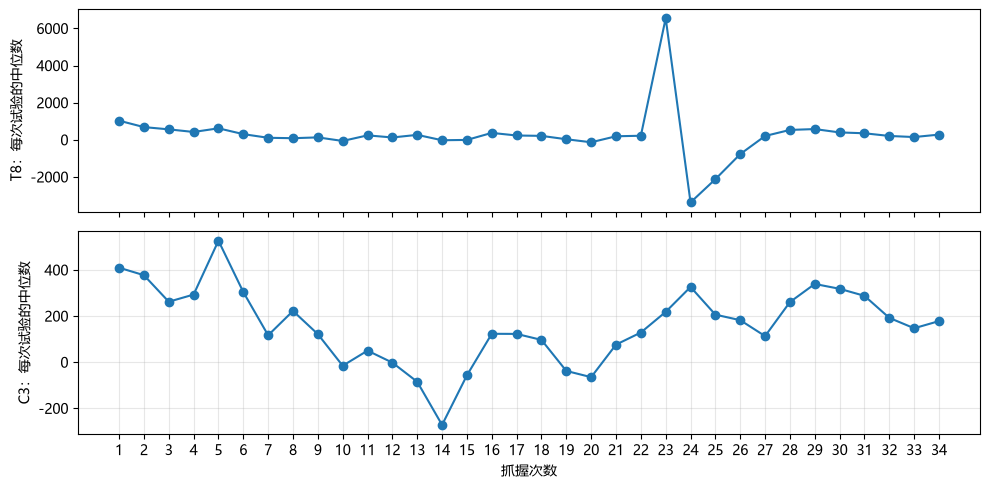

In [15]:
t8 = eeg_names.index("T8")

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

axes[0].plot(kept_lifts, np.median(X_batch[:, :, t8], axis=1), "o-")
axes[0].set_ylabel("T8：每次试验的中位数")

axes[1].plot(kept_lifts, np.median(X_batch[:, :, c3], axis=1), "o-")
axes[1].set_ylabel("C3：每次试验的中位数")
axes[1].set_xlabel("抓握次数")
axes[1].set_xticks(kept_lifts)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


C3 通道：
第 4次：中位数=   293.0，波动范围=   221.0
第 5次：中位数=   526.5，波动范围=   262.0
第 6次：中位数=   304.0，波动范围=   284.0
第13次：中位数=   -85.0，波动范围=   234.0
第14次：中位数=  -272.0，波动范围=   297.0
第15次：中位数=   -57.0，波动范围=   216.0

T8 通道：
第22次：中位数=   217.0，波动范围=   767.0
第23次：中位数=  6550.5，波动范围=  8438.0
第24次：中位数= -3376.0，波动范围=  2829.0
第25次：中位数= -2123.5，波动范围=  1369.0
第26次：中位数=  -772.5，波动范围=   793.0


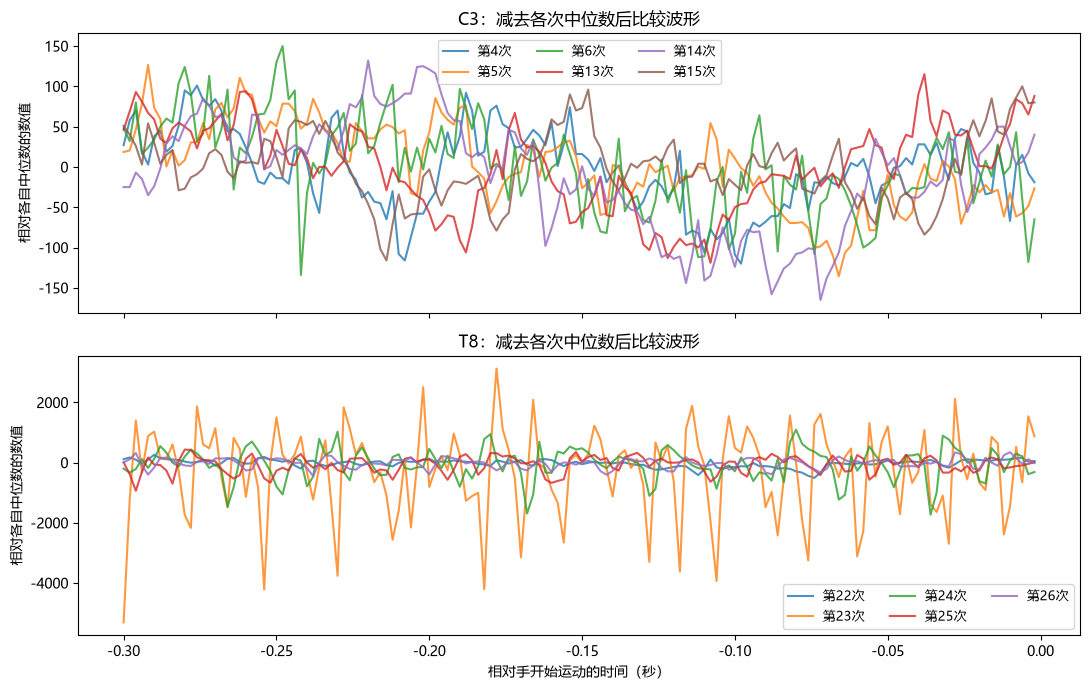

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
t = np.arange(n_before) / fs - n_before / fs

checks = [
    ("C3", [4, 5, 6, 13, 14, 15]),
    ("T8", [22, 23, 24, 25, 26]),
]

for ax, (channel, lifts) in zip(axes, checks):
    ch = eeg_names.index(channel)
    print(f"\n{channel} 通道：")

    for lift in lifts:
        i = kept_lifts.index(lift)
        signal = X_batch[i, :, ch]
        median = np.median(signal)
        spread = np.ptp(signal)  # 片段最大值 - 最小值

        print(f"第{lift:2d}次：中位数={median:8.1f}，波动范围={spread:8.1f}")
        ax.plot(t, signal - median, label=f"第{lift}次", alpha=0.8)

    ax.set_title(f"{channel}：减去各次中位数后比较波形")
    ax.set_ylabel("相对各自中位数的数值")
    ax.legend(ncol=3, fontsize=9)

axes[-1].set_xlabel("相对手开始运动的时间（秒）")
plt.tight_layout()
plt.show()

In [17]:
paper_channels = [
    "F3", "Fz", "F4", "FC5", "FC1", "FC2", "FC6",
    "C3", "Cz", "C4", "CP5", "CP1", "CP2", "CP6",
    "P7", "P3", "Pz", "P4", "O1", "Oz", "O2"
]

paper_indices = [eeg_names.index(name) for name in paper_channels]
X21_preview = X_batch[:, :, paper_indices]

print("论文通道数：", len(paper_channels))
print("当前选通道后的形状：", X21_preview.shape)
print("是否包含 T8：", "T8" in paper_channels)

论文通道数： 21
当前选通道后的形状： (34, 150, 21)
是否包含 T8： False


滤波前： (32, 119496)
滤波后： (32, 119496)


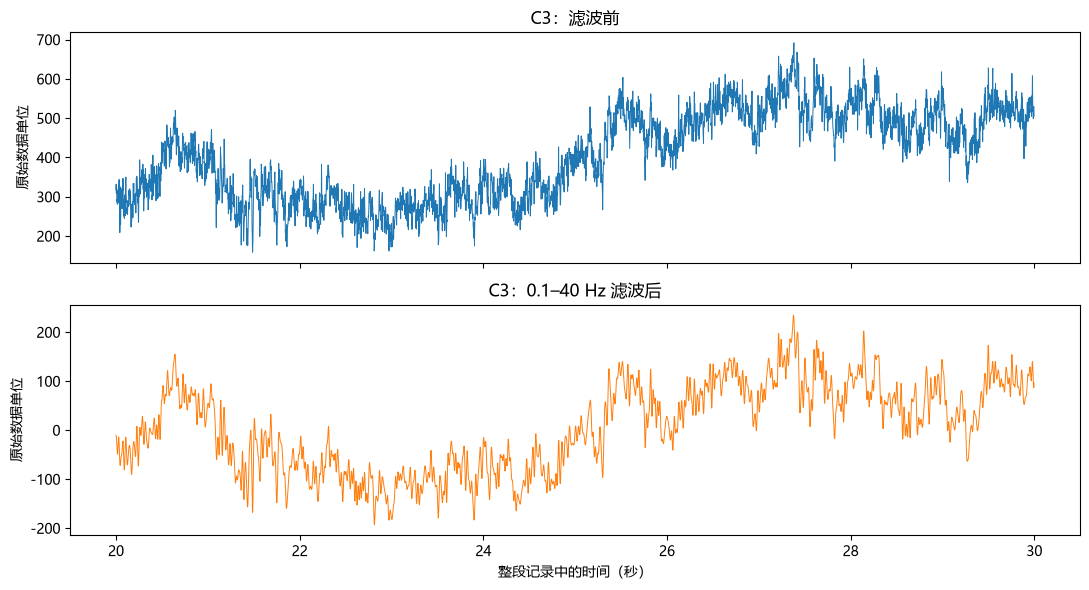

In [18]:
import mne

# HS 文件中的完整连续 EEG：原本是 时间点 × 32通道
eeg_continuous = hs.eeg.sig.T.astype(float)  # 改为 32通道 × 时间点

eeg_filtered = mne.filter.filter_data(
    eeg_continuous,
    sfreq=fs,
    l_freq=0.1,
    h_freq=40,
    method="fir",
    fir_design="firwin",
    phase="zero",
    verbose=False
)

print("滤波前：", eeg_continuous.shape)
print("滤波后：", eeg_filtered.shape)

# 先看同一段 C3：滤波前后对比
c3_idx = eeg_names.index("C3")
start, stop = 20 * fs, 30 * fs
time = np.arange(start, stop) / fs

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(time, eeg_continuous[c3_idx, start:stop], linewidth=0.7)
axes[0].set_title("C3：滤波前")

axes[1].plot(time, eeg_filtered[c3_idx, start:stop],
             linewidth=0.7, color="tab:orange")
axes[1].set_title("C3：0.1–40 Hz 滤波后")
axes[1].set_xlabel("整段记录中的时间（秒）")

for ax in axes:
    ax.set_ylabel("原始数据单位")
plt.tight_layout()
plt.show()

In [19]:
# eeg_filtered 是刚得到的完整连续记录，形状 (32, 119496)
eeg21_filtered = eeg_filtered[paper_indices, :].copy()

# 每个时间点，计算21个通道的平均值，再从各通道减去
reference = eeg21_filtered.mean(axis=0, keepdims=True)
eeg21_ref = eeg21_filtered - reference

print("重参考前：", eeg21_filtered.shape)
print("重参考后：", eeg21_ref.shape)
print("重参考后各时间点的通道均值最大偏差：",
      np.max(np.abs(eeg21_ref.mean(axis=0))))

重参考前： (21, 119496)
重参考后： (21, 119496)
重参考后各时间点的通道均值最大偏差： 9.473903143468003e-14


暂标记的坏通道： ['T8']
拟合出的 ICA 成分数： 30
准备排除的成分： []


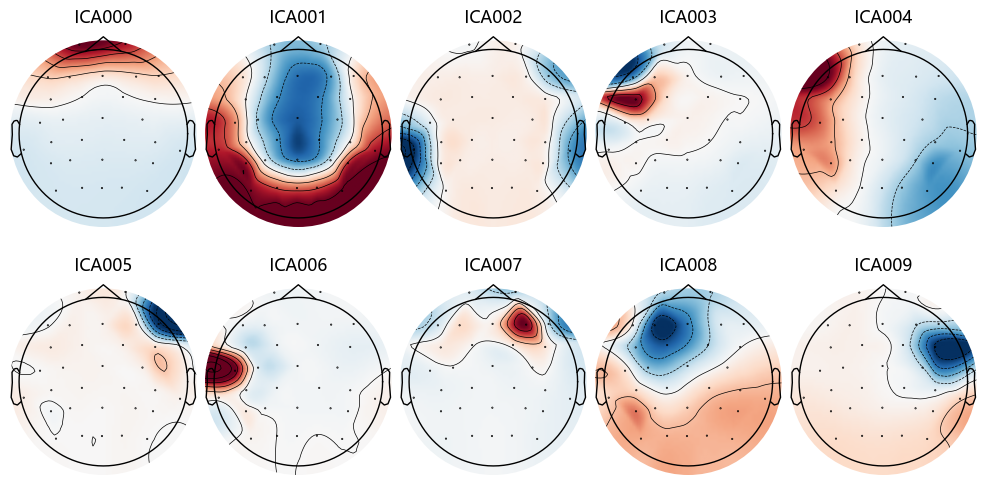

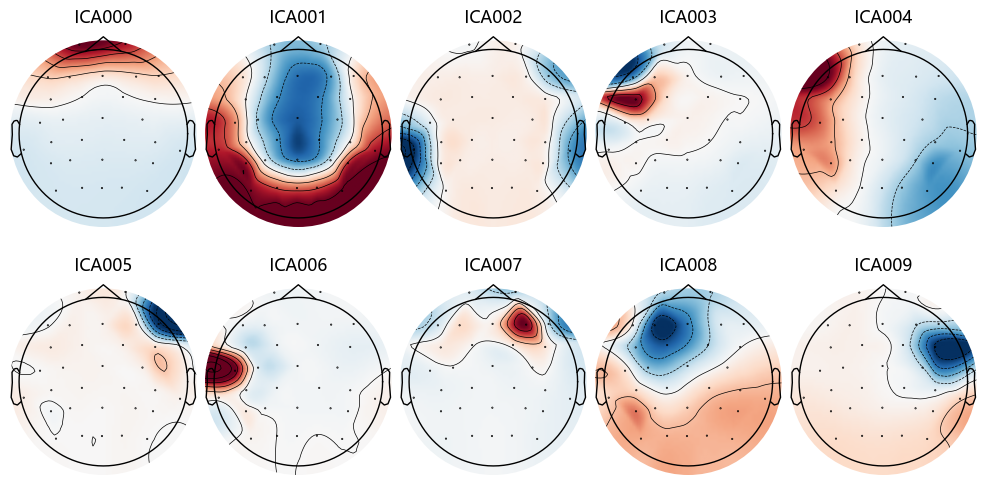

In [20]:
# 试运行假设：原始 EEG 数值单位为微伏，MNE 内部需要伏
# 正式复现前仍需核对数据单位
info = mne.create_info(eeg_names, sfreq=fs, ch_types="eeg")
raw32 = mne.io.RawArray(eeg_filtered * 1e-6, info, verbose=False)
raw32.set_montage("colin27_1020", on_missing="raise", verbose=False)

# 只对 P1 的 S1 暂时这样标记；不修改磁盘上的原始数据
raw32.info["bads"] = ["T8"]
raw_ref32 = raw32.copy().set_eeg_reference("average", verbose=False)

# ICA 拟合专用副本：1 Hz 高通有助于减轻慢漂移对拟合的干扰
raw_ica_fit = raw_ref32.copy().filter(
    l_freq=1.0, h_freq=None, picks="eeg", verbose=False
)

ica = mne.preprocessing.ICA(
    n_components=30,
    method="fastica",
    rng=97,
    max_iter=500
)
ica.fit(raw_ica_fit, picks="eeg", verbose=False)

print("暂标记的坏通道：", raw_ref32.info["bads"])
print("拟合出的 ICA 成分数：", ica.n_components_)
print("准备排除的成分：", ica.exclude)

ica.plot_components(picks=range(10))

    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
119 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
119 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
119 matching events found
No baseline correction applied
0 projection items activated


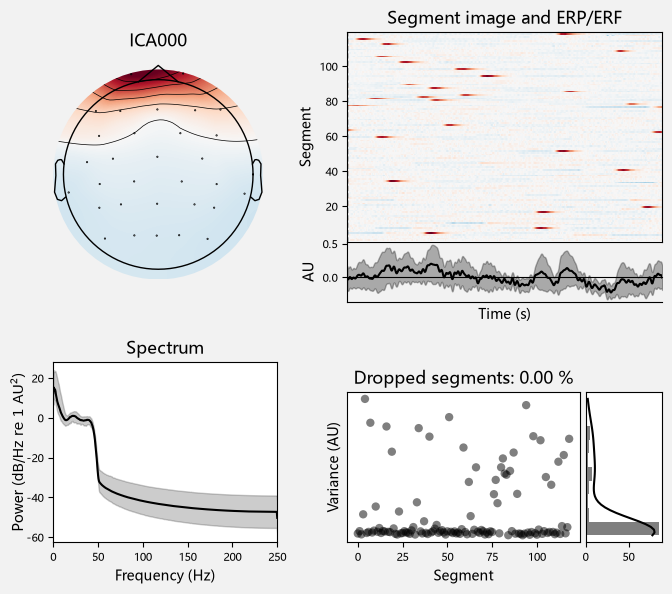

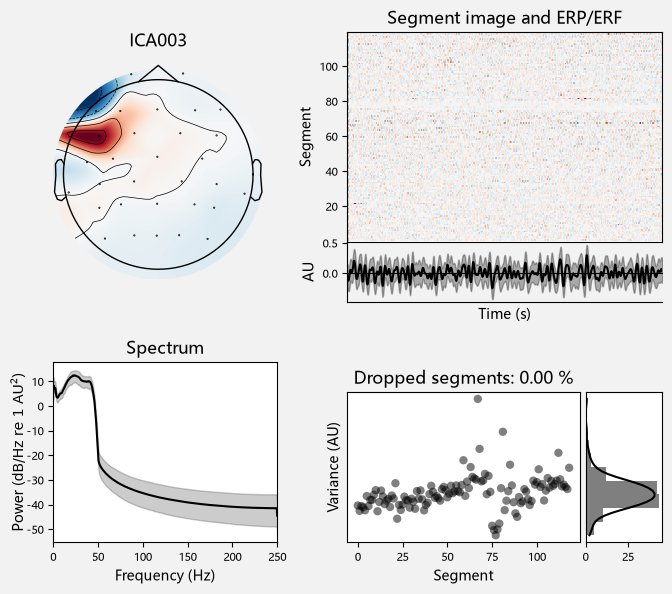

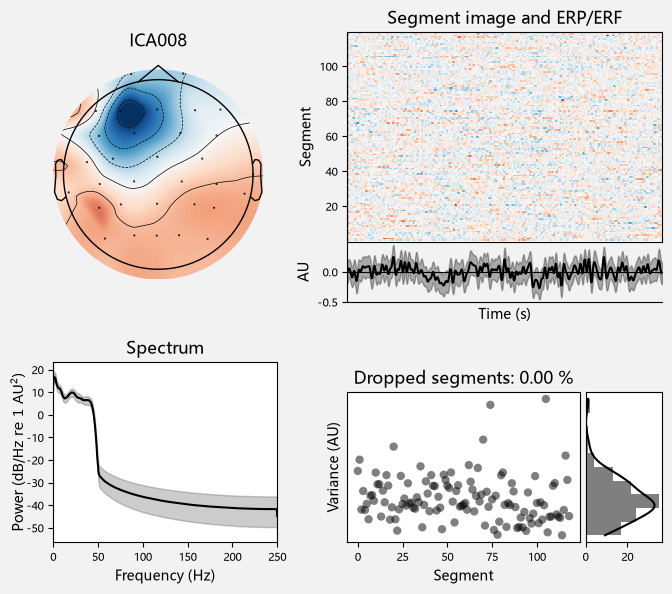

检查后当前排除列表： []


In [21]:
# 查看候选成分的头皮分布、时间变化和频谱
ica.plot_properties(
    raw_ica_fit,
    picks=[0, 3, 8]
)

print("检查后当前排除列表：", ica.exclude)

Applying ICA to Raw instance
    Transforming to ICA space (30 components)
    Zeroing out 1 ICA component
    Projecting back using 31 PCA components


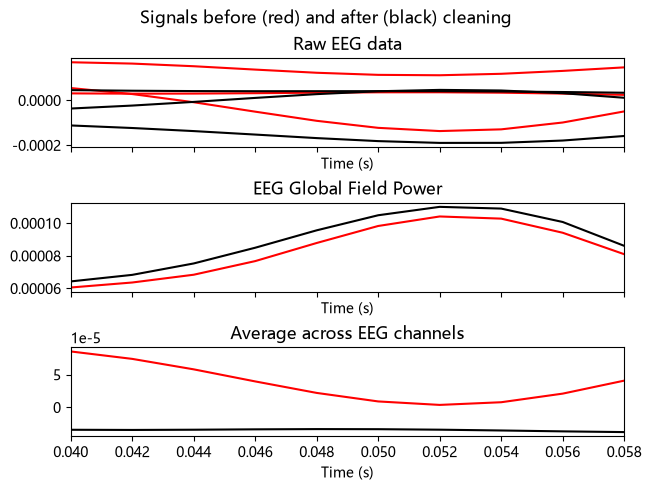

当前正式排除列表： []


In [22]:
# 只是预览效果；此时不修改 ica.exclude，也不覆盖原始数据
ica.plot_overlay(
    raw_ref32,
    exclude=[0],
    picks=["Fp1", "Fp2", "C3"],
    start=20,
    stop=30
)

print("当前正式排除列表：", ica.exclude)

In [23]:
print(ica.n_components_)
print(raw_ref32.info["bads"])

30
['T8']


Applying ICA to Raw instance
    Transforming to ICA space (30 components)
    Zeroing out 1 ICA component
    Projecting back using 31 PCA components


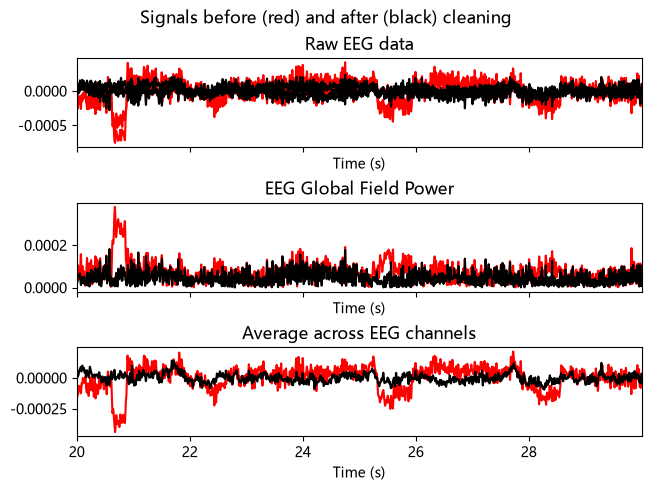

当前正式排除列表： []


In [24]:
ica.plot_overlay(
    raw_ref32,
    exclude=[0],
    picks=["Fp1", "Fp2", "C3"],
    start=20.0,
    stop=30.0
)
print("当前正式排除列表：", ica.exclude)

Applying ICA to Raw instance
    Transforming to ICA space (30 components)
    Zeroing out 1 ICA component
    Projecting back using 31 PCA components


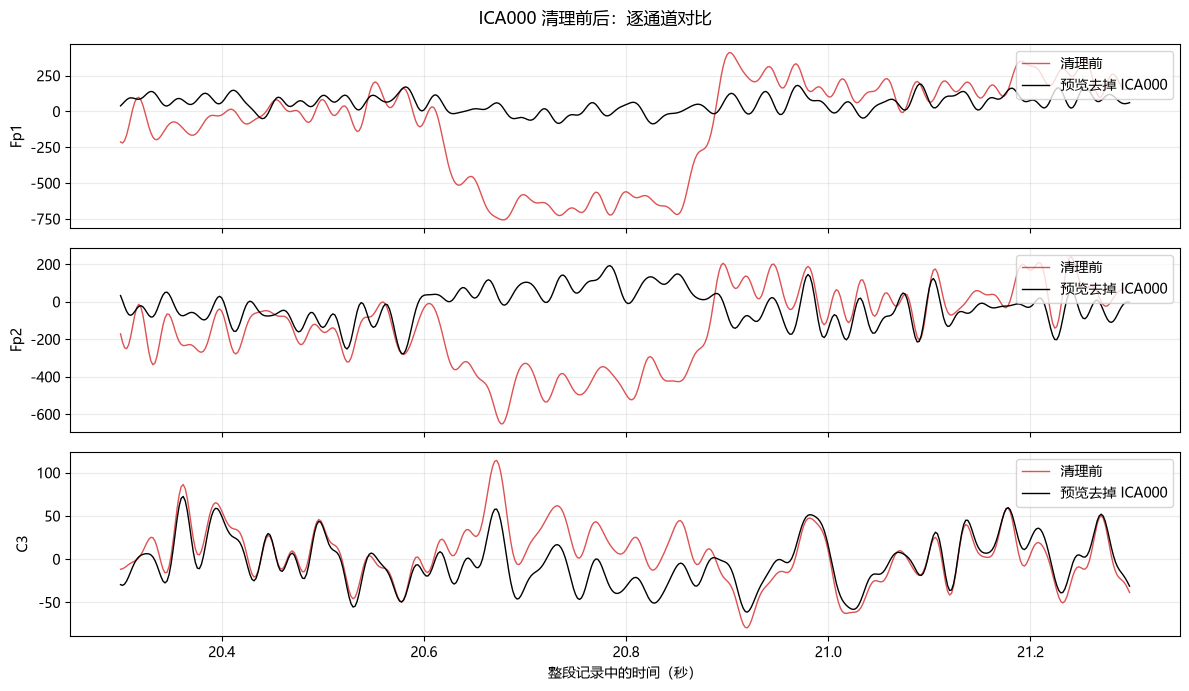

正式排除列表： []


In [25]:
import matplotlib.pyplot as plt

# 在副本上试验，不改 raw_ref32 或正式排除列表
clean_preview = raw_ref32.copy()
ica.apply(clean_preview, exclude=[0])

start, stop = raw_ref32.time_as_index([20.3, 21.3])
times = raw_ref32.times[start:stop]
channels = ["Fp1", "Fp2", "C3"]

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

for ax, ch in zip(axes, channels):
    before = raw_ref32.get_data(picks=[ch], start=start, stop=stop)[0] * 1e6
    after = clean_preview.get_data(picks=[ch], start=start, stop=stop)[0] * 1e6

    ax.plot(times, before, color="tab:red", linewidth=1, alpha=0.8, label="清理前")
    ax.plot(times, after, color="black", linewidth=1, label="预览去掉 ICA000")
    ax.set_ylabel(ch)
    ax.grid(alpha=0.25)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("整段记录中的时间（秒）")
fig.suptitle("ICA000 清理前后：逐通道对比")
plt.tight_layout()
plt.show()

print("正式排除列表：", ica.exclude)

In [26]:
ica.exclude = [0]
raw_clean = raw_ref32.copy()
ica.apply(raw_clean)

Applying ICA to Raw instance
    Transforming to ICA space (30 components)
    Zeroing out 1 ICA component
    Projecting back using 31 PCA components


<RawArray | 32 x 119496 (239.0 s), ~29.2 MiB, data loaded>

In [30]:
import matplotlib.pyplot as plt

# 创建预览副本；不改原始 raw_ref32
clean_preview = raw_ref32.copy()
ica.apply(clean_preview, exclude=[0])

channels = ["Fp1", "Fp2", "C3"]
windows = [(25.0, 26.0), (27.8, 28.8)]

for t0, t1 in windows:
    start, stop = raw_ref32.time_as_index([t0, t1])
    times = raw_ref32.times[start:stop]

    fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

    for ax, ch in zip(axes, channels):
        before = raw_ref32.get_data(
            picks=[ch], start=start, stop=stop
        )[0] * 1e6
        after = clean_preview.get_data(
            picks=[ch], start=start, stop=stop
        )[0] * 1e6

        ax.plot(times, before, color="tab:red", linewidth=1, label="清理前")
        ax.plot(times, after, color="black", linewidth=1, label="预览去掉 ICA000")
        ax.set_ylabel(ch)
        ax.grid(alpha=0.25)
        ax.legend(loc="upper right")

    axes[-1].set_xlabel("整段记录中的时间（秒）")
    fig.suptitle(f"ICA000 清理前后：{t0}–{t1} 秒")
    plt.tight_layout()
    plt.show()

print("正式排除列表：", ica.exclude)

SyntaxError: invalid syntax (2674268492.py, line 35)

Applying ICA to Raw instance
    Transforming to ICA space (30 components)
    Zeroing out 1 ICA component
    Projecting back using 31 PCA components


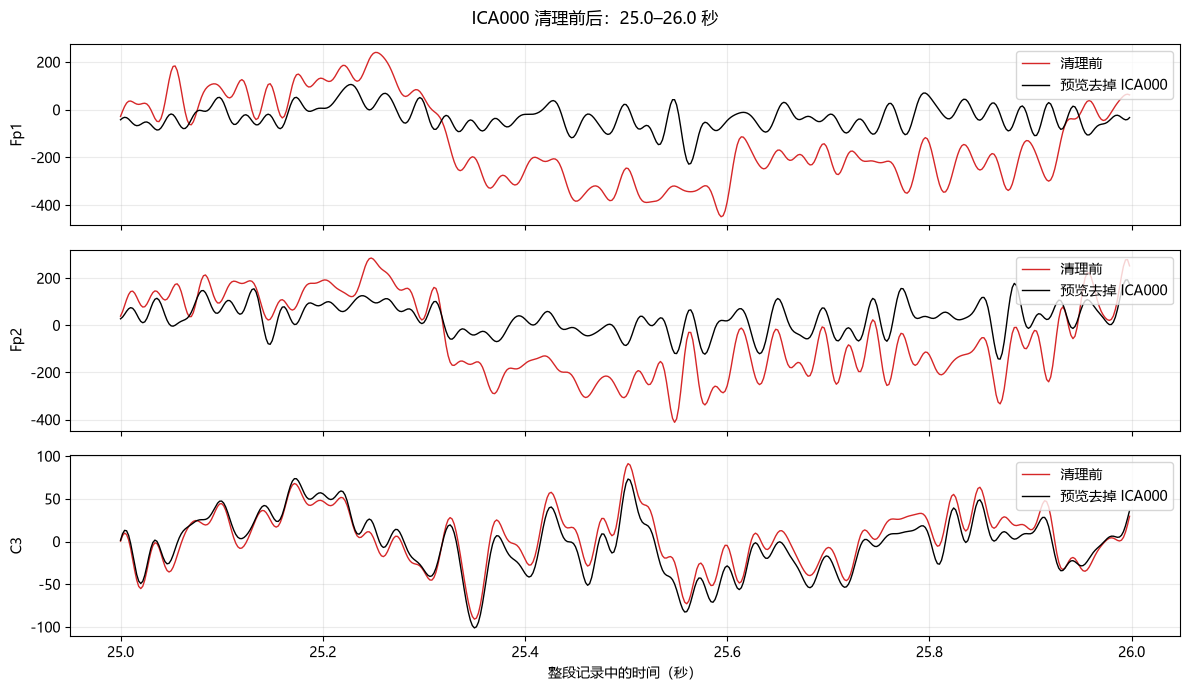

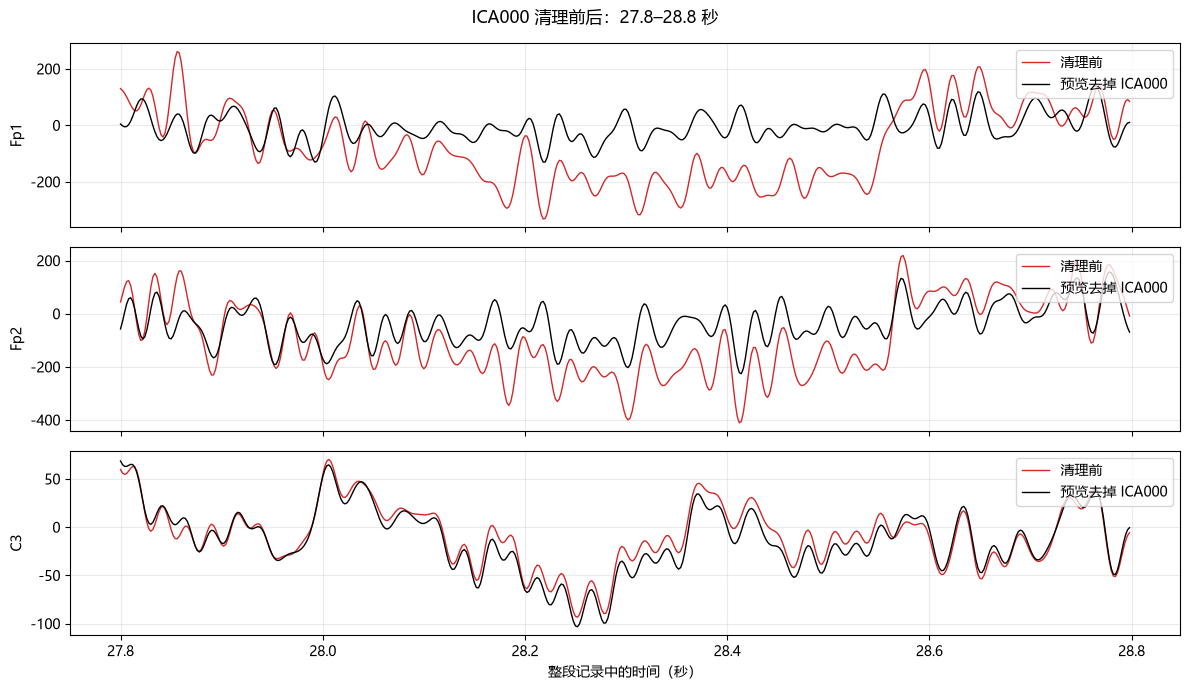

正式排除列表： [0]


In [31]:
import matplotlib.pyplot as plt

# 创建预览副本；不改原始 raw_ref32
clean_preview = raw_ref32.copy()
ica.apply(clean_preview, exclude=[0])

channels = ["Fp1", "Fp2", "C3"]
windows = [(25.0, 26.0), (27.8, 28.8)]

for t0, t1 in windows:
    start, stop = raw_ref32.time_as_index([t0, t1])
    times = raw_ref32.times[start:stop]

    fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

    for ax, ch in zip(axes, channels):
        before = raw_ref32.get_data(
            picks=[ch], start=start, stop=stop
        )[0] * 1e6
        after = clean_preview.get_data(
            picks=[ch], start=start, stop=stop
        )[0] * 1e6

        ax.plot(times, before, color="tab:red", linewidth=1, label="清理前")
        ax.plot(times, after, color="black", linewidth=1, label="预览去掉 ICA000")
        ax.set_ylabel(ch)
        ax.grid(alpha=0.25)
        ax.legend(loc="upper right")

    axes[-1].set_xlabel("整段记录中的时间（秒）")
    fig.suptitle(f"ICA000 清理前后：{t0}–{t1} 秒")
    plt.tight_layout()
    plt.show()

print("正式排除列表：", ica.exclude)

In [33]:
ica.exclude = [0]  # 暂定排除 ICA000：额头大幅慢波在多个窗口中减小
raw_clean = ica.apply(raw_ref32.copy())

print("排除的 ICA 成分：", ica.exclude)
print("清理后数据形状：", raw_clean.get_data().shape)

Applying ICA to Raw instance
    Transforming to ICA space (30 components)
    Zeroing out 1 ICA component
    Projecting back using 31 PCA components
排除的 ICA 成分： [0]
清理后数据形状： (32, 119496)


In [34]:
start_col = columns.index("StartTime")
rows_by_lift = {
    int(row[lift_col]): row
    for row in run1_rows
}

X_clean_list = []

for lift in kept_lifts:
    row = rows_by_lift[lift]
    current_win = ws.win[lift - 1]

    # WS 窗口首个样本在连续 EEG 中的位置
    window_start = round((float(row[start_col]) - 2.0) * fs)

    # 核对两个数据文件确实指向同一段 EEG
    assert np.array_equal(
        hs.eeg.sig[window_start:window_start + 10, c3],
        current_win.eeg[:10, c3]
    ), f"第 {lift} 次抓握未对齐"

    onset = float(row[columns.index("tHandStart")])
    onset_in_window = np.searchsorted(current_win.eeg_t, onset)
    onset_in_continuous = window_start + onset_in_window

    eeg_start = onset_in_continuous - n_before
    eeg_stop = onset_in_continuous

    eeg_part = raw_clean.get_data(
        picks=paper_channels,
        start=eeg_start,
        stop=eeg_stop
    ).T  # 时间点 × 21 通道

    X_clean_list.append(eeg_part)

X_clean = np.stack(X_clean_list)

print("清理后 EEG：", X_clean.shape)
print("原有轨迹目标：", Y_batch.shape)
print("数值均有限：", np.isfinite(X_clean).all())

清理后 EEG： (34, 150, 21)
原有轨迹目标： (34, 500, 3)
数值均有限： True


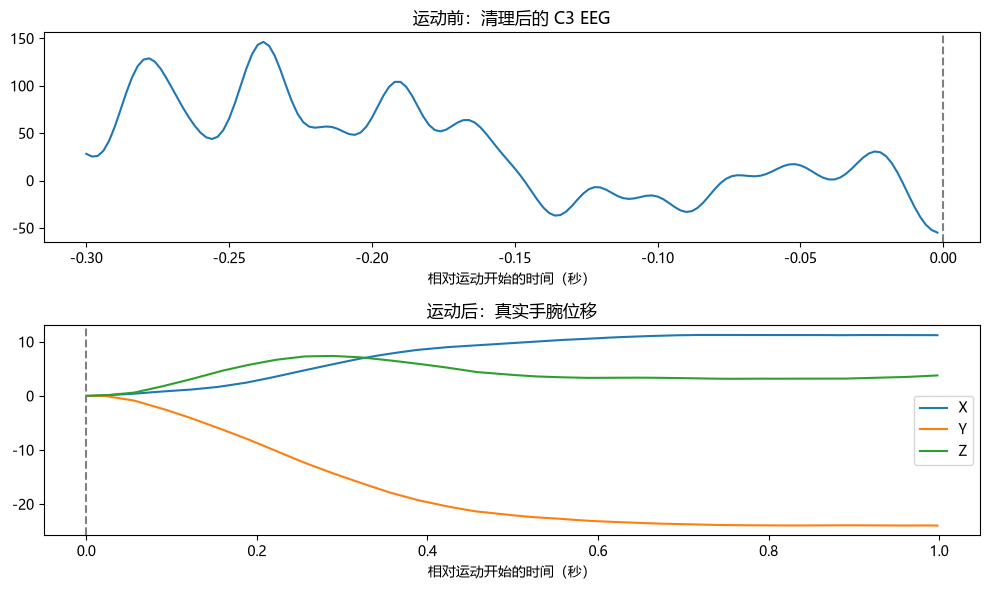

In [35]:
i = kept_lifts.index(4)  # 第 4 次抓握
t_eeg = np.arange(X_clean.shape[1]) / fs - X_clean.shape[1] / fs
t_traj = np.arange(Y_batch.shape[1]) / fs

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

axes[0].plot(t_eeg, X_clean[i, :, paper_channels.index("C3")] * 1e6)
axes[0].axvline(0, color="gray", linestyle="--")
axes[0].set_title("运动前：清理后的 C3 EEG")
axes[0].set_xlabel("相对运动开始的时间（秒）")

for j, name in enumerate(("X", "Y", "Z")):
    axes[1].plot(t_traj, Y_batch[i, :, j], label=name)
axes[1].axvline(0, color="gray", linestyle="--")
axes[1].set_title("运动后：真实手腕位移")
axes[1].set_xlabel("相对运动开始的时间（秒）")
axes[1].legend()

plt.tight_layout()
plt.show()

In [36]:
n_train = int(len(Y_batch) * 0.8)  # 前 27 次训练，后 7 次测试
Y_train = Y_batch[:n_train]
Y_test = Y_batch[n_train:]

mean_trajectory = Y_train.mean(axis=0)  # (500, 3)
Y_baseline = np.repeat(
    mean_trajectory[None, :, :],
    len(Y_test),
    axis=0
)

mae_xyz = np.mean(np.abs(Y_baseline - Y_test), axis=(0, 1))

print("训练试次：", len(Y_train))
print("测试试次：", len(Y_test))
print("平均轨迹基线 MAE（X、Y、Z）：", mae_xyz)

训练试次： 27
测试试次： 7
平均轨迹基线 MAE（X、Y、Z）： [0.5523181  0.82229585 0.64058892]


In [37]:
from scipy.signal import butter, sosfilt

# 选择 21 通道，并在每个时间点做平均重参考
eeg21 = hs.eeg.sig[:, paper_indices].astype(float)
eeg21 = eeg21 - eeg21.mean(axis=1, keepdims=True)

# 从记录开头向后滤波；不使用未来采样点
sos = butter(
    4, [0.1, 40],
    btype="bandpass",
    fs=fs,
    output="sos"
)
eeg_causal = sosfilt(sos, eeg21, axis=0)

# 按之前核对过的事件位置，切出同样的 34 次、运动前 0.3 秒
rows_by_lift = {int(row[lift_col]): row for row in run1_rows}
X_causal_list = []

for lift in kept_lifts:
    row = rows_by_lift[lift]
    win = ws.win[lift - 1]

    window_start = round((float(row[columns.index("StartTime")]) - 2.0) * fs)
    onset = float(row[columns.index("tHandStart")])
    onset_in_window = np.searchsorted(win.eeg_t, onset)
    onset_in_continuous = window_start + onset_in_window

    eeg_part = eeg_causal[
        onset_in_continuous - n_before:onset_in_continuous, :
    ]
    X_causal_list.append(eeg_part)

X_causal = np.stack(X_causal_list)

print("因果处理后的 EEG：", X_causal.shape)
print("目标轨迹：", Y_batch.shape)
print("数值均有限：", np.isfinite(X_causal).all())

因果处理后的 EEG： (34, 150, 21)
目标轨迹： (34, 500, 3)
数值均有限： True


In [38]:
# 每次抓握：3 个时间段 × 21 通道 = 63 个特征
n = len(X_causal)
features = np.log(
    np.std(X_causal.reshape(n, 3, 50, 21), axis=2) + 1e-8
).reshape(n, -1)

n_train = 27
F_train, F_test = features[:n_train], features[n_train:]
Y_train, Y_test = Y_batch[:n_train], Y_batch[n_train:]

# 只用训练集确定标准化参数
feature_mean = F_train.mean(axis=0)
feature_std = F_train.std(axis=0)
feature_std[feature_std < 1e-12] = 1

F_train = (F_train - feature_mean) / feature_std
F_test = (F_test - feature_mean) / feature_std

# 固定正则强度的岭回归；一次预测 500 × 3 个轨迹数值
target_train = Y_train.reshape(n_train, -1)
target_mean = target_train.mean(axis=0)
alpha = 100.0

weights = np.linalg.solve(
    F_train.T @ F_train + alpha * np.eye(F_train.shape[1]),
    F_train.T @ (target_train - target_mean)
)

Y_pred = (F_test @ weights + target_mean).reshape(-1, 500, 3)

model_mae = np.mean(np.abs(Y_pred - Y_test), axis=(0, 1))
baseline_mae = np.mean(np.abs(Y_baseline - Y_test), axis=(0, 1))

print("平均轨迹基线 MAE：", baseline_mae)
print("EEG 岭回归模型 MAE：", model_mae)

平均轨迹基线 MAE： [0.5523181  0.82229585 0.64058892]
EEG 岭回归模型 MAE： [0.51289828 0.80696516 0.63159844]


In [39]:
baseline_each = np.mean(np.abs(Y_baseline - Y_test), axis=(1, 2))
model_each = np.mean(np.abs(Y_pred - Y_test), axis=(1, 2))

for lift, base_err, model_err in zip(
    kept_lifts[n_train:], baseline_each, model_each
):
    print(
        f"第 {lift:2d} 次抓握 | "
        f"基线 {base_err:.3f} | "
        f"EEG {model_err:.3f} | "
        f"{'EEG更好' if model_err < base_err else '基线更好'}"
    )

第 28 次抓握 | 基线 0.630 | EEG 0.693 | 基线更好
第 29 次抓握 | 基线 0.351 | EEG 0.362 | 基线更好
第 30 次抓握 | 基线 0.441 | EEG 0.465 | 基线更好
第 31 次抓握 | 基线 0.689 | EEG 0.528 | EEG更好
第 32 次抓握 | 基线 0.746 | EEG 0.709 | EEG更好
第 33 次抓握 | 基线 1.042 | EEG 0.901 | EEG更好
第 34 次抓握 | 基线 0.803 | EEG 0.895 | 基线更好


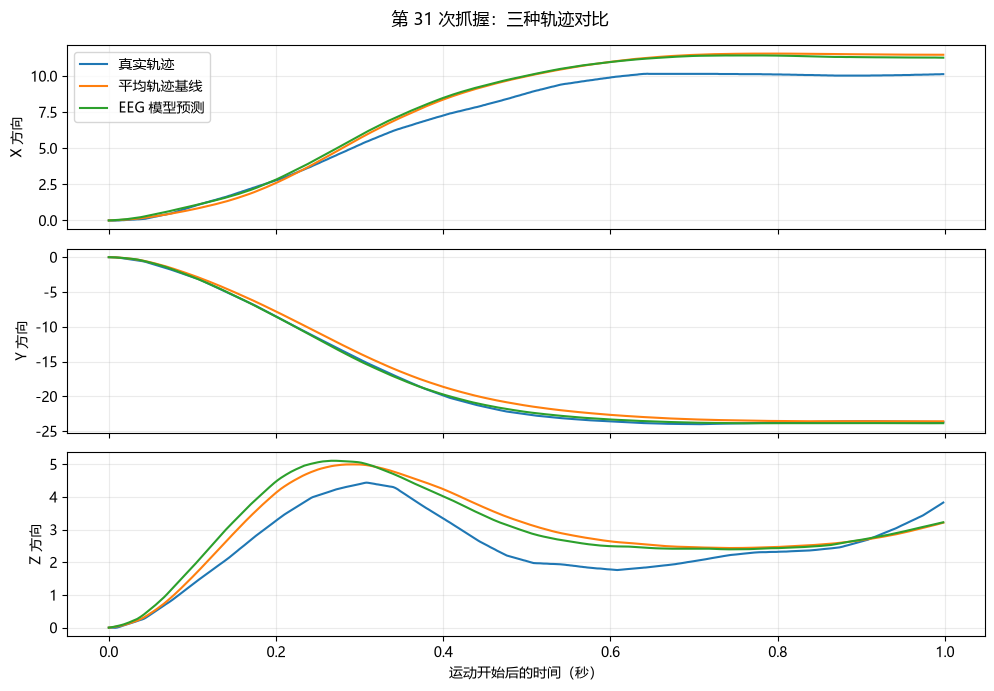

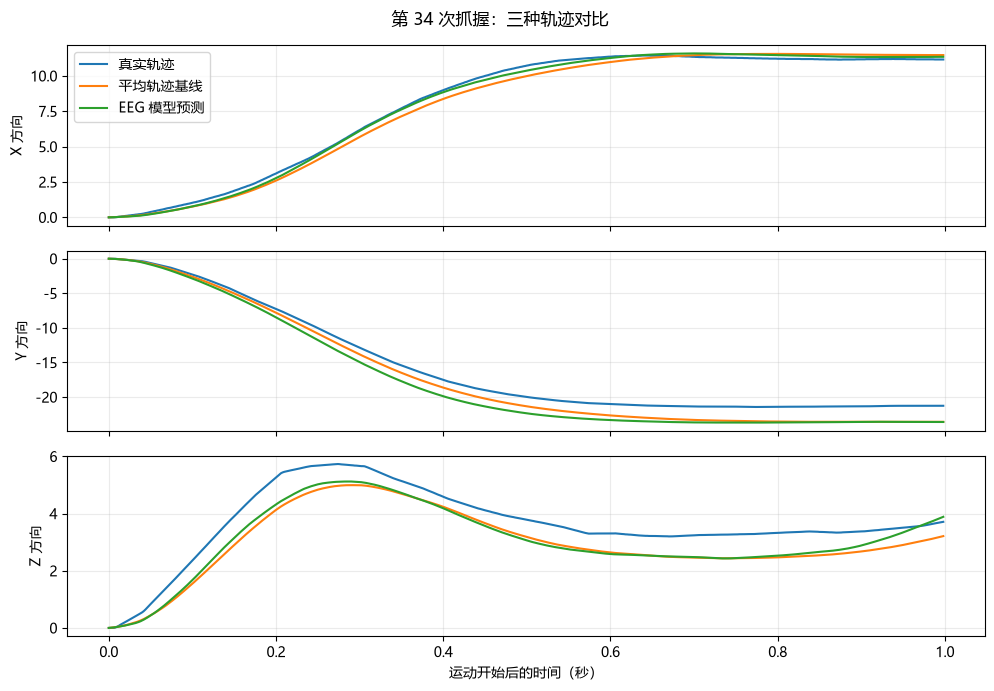

In [40]:
test_lifts = kept_lifts[n_train:]
time_after = np.arange(Y_test.shape[1]) / fs

for lift in (31, 34):
    j = test_lifts.index(lift)
    fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

    for k, name in enumerate(("X", "Y", "Z")):
        axes[k].plot(time_after, Y_test[j, :, k], label="真实轨迹")
        axes[k].plot(time_after, Y_baseline[j, :, k], label="平均轨迹基线")
        axes[k].plot(time_after, Y_pred[j, :, k], label="EEG 模型预测")
        axes[k].set_ylabel(f"{name} 方向")
        axes[k].grid(alpha=0.25)

    axes[0].legend()
    axes[-1].set_xlabel("运动开始后的时间（秒）")
    fig.suptitle(f"第 {lift} 次抓握：三种轨迹对比")
    plt.tight_layout()
    plt.show()

In [41]:
rng = np.random.default_rng(42)
n_permutations = 200

# 整体 MAE：同时平均测试试次、时间点和三个方向
observed_mae = np.mean(np.abs(Y_pred - Y_test))
baseline_overall_mae = np.mean(np.abs(Y_baseline - Y_test))

target_train = Y_train.reshape(n_train, -1)
target_mean = target_train.mean(axis=0)

# 特征和正则强度保持与刚才相同
ridge_map = np.linalg.solve(
    F_train.T @ F_train + alpha * np.eye(F_train.shape[1]),
    F_train.T
)

shuffled_mae = []

for _ in range(n_permutations):
    shuffled_targets = target_train[rng.permutation(n_train)]
    shuffled_weights = ridge_map @ (shuffled_targets - target_mean)
    shuffled_pred = (
        F_test @ shuffled_weights + target_mean
    ).reshape(Y_test.shape)

    shuffled_mae.append(np.mean(np.abs(shuffled_pred - Y_test)))

shuffled_mae = np.array(shuffled_mae)
p_value = (1 + np.sum(shuffled_mae <= observed_mae)) / (n_permutations + 1)

print("平均轨迹基线整体 MAE：", baseline_overall_mae)
print("正确配对 EEG 模型 MAE：", observed_mae)
print("打乱配对后的 MAE 均值：", shuffled_mae.mean())
print("打乱后仍优于正确配对的比例（含校正）：", p_value)

平均轨迹基线整体 MAE： 0.6717342899470896
正确配对 EEG 模型 MAE： 0.6504872935360343
打乱配对后的 MAE 均值： 0.7100732139586237
打乱后仍优于正确配对的比例（含校正）： 0.08955223880597014


In [42]:
from scipy.io import loadmat
from scipy.signal import butter, sosfilt

X_all_list, Y_all_list, run_ids = [], [], []

start_col = columns.index("StartTime")
onset_col = columns.index("tHandStart")

for run in range(1, 10):
    hs_run = loadmat(
        data_dir / f"HS_P1_S{run}.mat",
        struct_as_record=False,
        squeeze_me=True
    )["hs"]
    ws_run = loadmat(
        data_dir / f"WS_P1_S{run}.mat",
        struct_as_record=False,
        squeeze_me=True
    )["ws"]

    eeg_names_run = list(hs_run.eeg.names)
    kin_names_run = list(hs_run.kin.names)

    eeg_cols = [eeg_names_run.index(name) for name in paper_channels]
    wrist_cols = [
        next(i for i, name in enumerate(kin_names_run)
             if str(name).startswith(axis + " "))
        for axis in ("Px4", "Py4", "Pz4")
    ]

    eeg21 = hs_run.eeg.sig[:, eeg_cols].astype(float)
    eeg21 -= eeg21.mean(axis=1, keepdims=True)

    sos = butter(4, [0.1, 40], btype="bandpass", fs=fs, output="sos")
    eeg_causal_run = sosfilt(sos, eeg21, axis=0)

    rows = P.AllLifts[P.AllLifts[:, run_col] == run]
    count = 0

    for row in rows:
        lift = int(row[lift_col])
        win = ws_run.win[lift - 1]
        onset = float(row[onset_col])

        window_start = round((float(row[start_col]) - 2.0) * fs)
        onset_in_window = np.searchsorted(win.eeg_t, onset)
        onset_in_continuous = window_start + onset_in_window

        # 核对 WS 窗口与 HS 连续记录的对齐
        c3_run = eeg_names_run.index("C3")
        assert np.array_equal(
            hs_run.eeg.sig[window_start:window_start + 10, c3_run],
            win.eeg[:10, c3_run]
        ), f"第 {run} 段、第 {lift} 次抓握未对齐"

        x = eeg_causal_run[
            onset_in_continuous - n_before:onset_in_continuous, :
        ]
        y = win.kin[
            onset_in_window:onset_in_window + n_after, wrist_cols
        ]
        y = y - y[0]

        assert x.shape == (150, 21) and y.shape == (500, 3)
        assert np.isfinite(x).all() and np.isfinite(y).all()

        X_all_list.append(x)
        Y_all_list.append(y)
        run_ids.append(run)
        count += 1

    print(f"第 {run} 段：{count} 次抓握")

X_all = np.stack(X_all_list)
Y_all = np.stack(Y_all_list)
run_ids = np.array(run_ids)

print("全部 EEG：", X_all.shape)
print("全部轨迹：", Y_all.shape)
print("前 8 段 / 第 9 段：",
      np.sum(run_ids <= 8), "/", np.sum(run_ids == 9))

第 1 段：34 次抓握
第 2 段：34 次抓握
第 3 段：28 次抓握
第 4 段：34 次抓握
第 5 段：28 次抓握
第 6 段：34 次抓握
第 7 段：34 次抓握
第 8 段：34 次抓握
第 9 段：34 次抓握
全部 EEG： (294, 150, 21)
全部轨迹： (294, 500, 3)
前 8 段 / 第 9 段： 260 / 34


In [43]:
# 每次抓握提取 3 个时间段 × 21 通道的波动特征
n = len(X_all)
F_all = np.log(
    np.std(X_all.reshape(n, 3, 50, 21), axis=2) + 1e-8
).reshape(n, -1)

train_mask = run_ids <= 8
test_mask = run_ids == 9

F_train = F_all[train_mask]
F_test = F_all[test_mask]
Y_train = Y_all[train_mask]
Y_test = Y_all[test_mask]

# 标准化参数只从训练段计算
feature_mean = F_train.mean(axis=0)
feature_std = F_train.std(axis=0)
feature_std[feature_std < 1e-12] = 1

F_train = (F_train - feature_mean) / feature_std
F_test = (F_test - feature_mean) / feature_std

# 平均轨迹基线
mean_trajectory = Y_train.mean(axis=0)
Y_baseline = np.repeat(
    mean_trajectory[None, :, :], len(Y_test), axis=0
)

# EEG 岭回归模型，先固定 alpha，不根据测试段调参
target_train = Y_train.reshape(len(Y_train), -1)
target_mean = target_train.mean(axis=0)
alpha = 100.0

weights = np.linalg.solve(
    F_train.T @ F_train + alpha * np.eye(F_train.shape[1]),
    F_train.T @ (target_train - target_mean)
)
Y_pred = (F_test @ weights + target_mean).reshape(Y_test.shape)

baseline_mae = np.mean(np.abs(Y_baseline - Y_test), axis=(0, 1))
model_mae = np.mean(np.abs(Y_pred - Y_test), axis=(0, 1))

baseline_each = np.mean(np.abs(Y_baseline - Y_test), axis=(1, 2))
model_each = np.mean(np.abs(Y_pred - Y_test), axis=(1, 2))

print("测试抓握数：", len(Y_test))
print("基线 MAE（X、Y、Z）：", baseline_mae)
print("EEG 模型 MAE（X、Y、Z）：", model_mae)
print("基线整体 MAE：", baseline_each.mean())
print("EEG 整体 MAE：", model_each.mean())
print("EEG 优于基线的抓握数：", np.sum(model_each < baseline_each))

测试抓握数： 34
基线 MAE（X、Y、Z）： [0.46579827 1.87447357 0.52814038]
EEG 模型 MAE（X、Y、Z）： [0.55025028 1.60121327 0.50203419]
基线整体 MAE： 0.9561374059125187
EEG 整体 MAE： 0.8844992477928666
EEG 优于基线的抓握数： 21


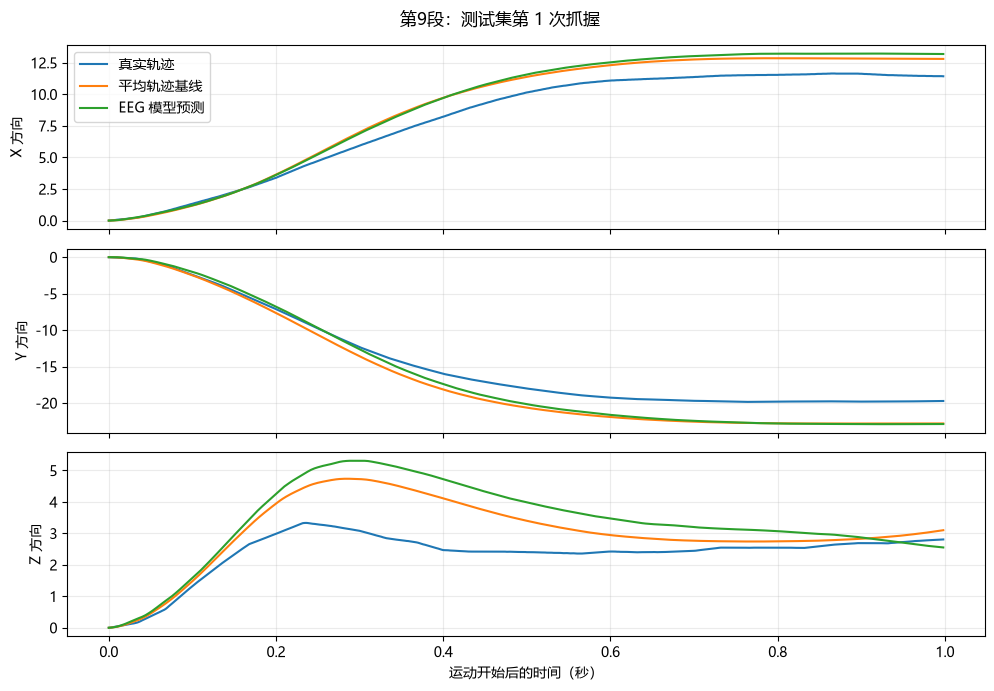

In [44]:
j = 0  # 第9段测试集的第1次；可改为 0～33
time_after = np.arange(Y_test.shape[1]) / fs

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

for k, name in enumerate(("X", "Y", "Z")):
    axes[k].plot(time_after, Y_test[j, :, k], label="真实轨迹")
    axes[k].plot(time_after, Y_baseline[j, :, k], label="平均轨迹基线")
    axes[k].plot(time_after, Y_pred[j, :, k], label="EEG 模型预测")
    axes[k].set_ylabel(f"{name} 方向")
    axes[k].grid(alpha=0.25)

axes[0].legend()
axes[-1].set_xlabel("运动开始后的时间（秒）")
fig.suptitle(f"第9段：测试集第 {j + 1} 次抓握")
plt.tight_layout()
plt.show()

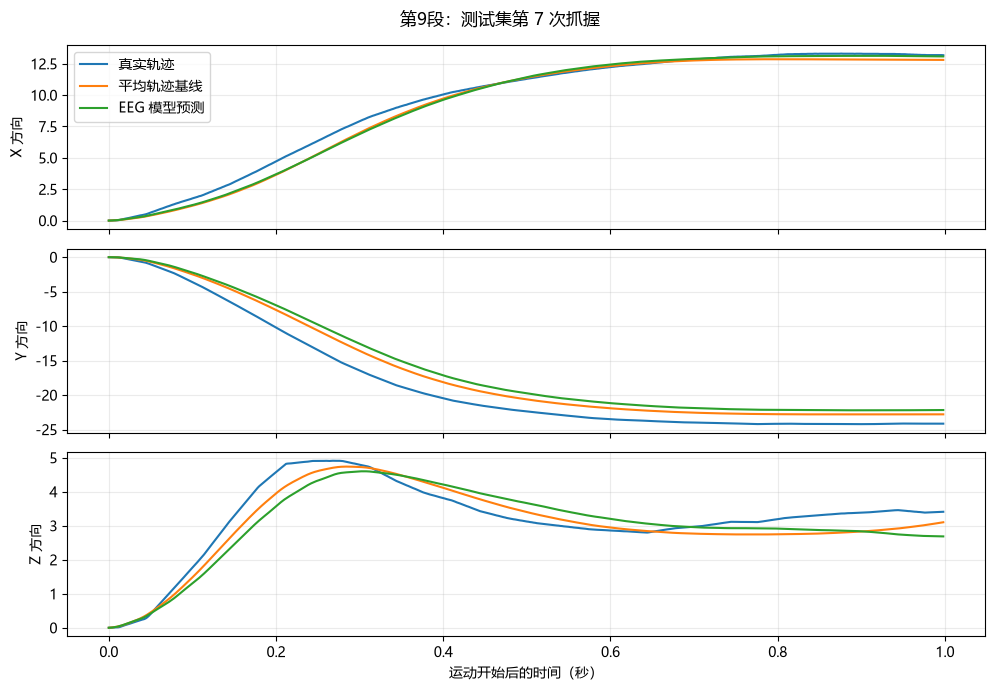

In [45]:
j = 6  # 第9段测试集的第1次；可改为 0～33
time_after = np.arange(Y_test.shape[1]) / fs

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

for k, name in enumerate(("X", "Y", "Z")):
    axes[k].plot(time_after, Y_test[j, :, k], label="真实轨迹")
    axes[k].plot(time_after, Y_baseline[j, :, k], label="平均轨迹基线")
    axes[k].plot(time_after, Y_pred[j, :, k], label="EEG 模型预测")
    axes[k].set_ylabel(f"{name} 方向")
    axes[k].grid(alpha=0.25)

axes[0].legend()
axes[-1].set_xlabel("运动开始后的时间（秒）")
fig.suptitle(f"第9段：测试集第 {j + 1} 次抓握")
plt.tight_layout()
plt.show()

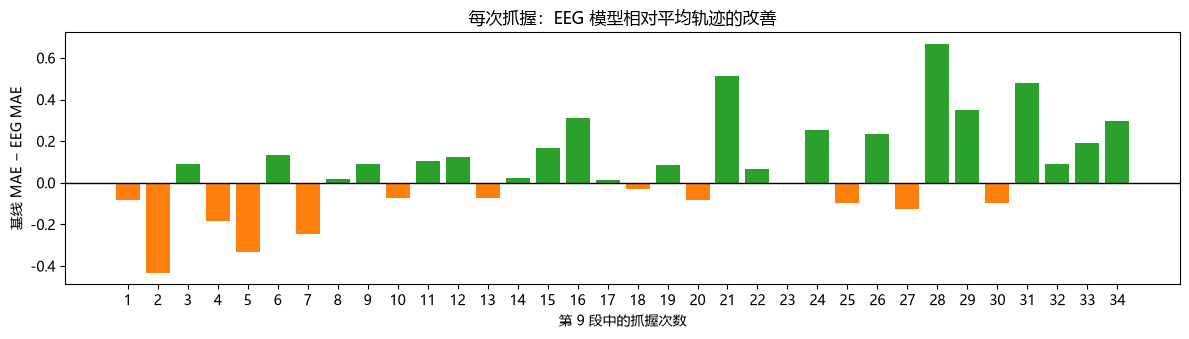

第 1 次抓握：
基线 MAE： 1.2127781753846147
EEG MAE： 1.2952513381374013


In [46]:
improvement = baseline_each - model_each
trial_numbers = np.arange(1, len(improvement) + 1)

plt.figure(figsize=(12, 3.5))
plt.bar(
    trial_numbers,
    improvement,
    color=np.where(improvement > 0, "tab:green", "tab:orange")
)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("第 9 段中的抓握次数")
plt.ylabel("基线 MAE − EEG MAE")
plt.title("每次抓握：EEG 模型相对平均轨迹的改善")
plt.xticks(trial_numbers)
plt.tight_layout()
plt.show()

print("第 1 次抓握：")
print("基线 MAE：", baseline_each[0])
print("EEG MAE：", model_each[0])

In [47]:
results_by_run = []

for test_run in range(1, 10):
    train = run_ids != test_run
    test = run_ids == test_run

    F_tr = F_all[train].copy()
    F_te = F_all[test].copy()
    Y_tr = Y_all[train]
    Y_te = Y_all[test]

    # 每轮只用训练段计算标准化参数
    mu = F_tr.mean(axis=0)
    sd = F_tr.std(axis=0)
    sd[sd < 1e-12] = 1
    F_tr = (F_tr - mu) / sd
    F_te = (F_te - mu) / sd

    # 平均轨迹基线
    mean_traj = Y_tr.mean(axis=0)
    baseline = np.repeat(mean_traj[None, :, :], len(Y_te), axis=0)

    # 与前面相同的固定参数岭回归
    target = Y_tr.reshape(len(Y_tr), -1)
    target_mean = target.mean(axis=0)
    weights_run = np.linalg.solve(
        F_tr.T @ F_tr + 100.0 * np.eye(F_tr.shape[1]),
        F_tr.T @ (target - target_mean)
    )
    predicted = (F_te @ weights_run + target_mean).reshape(Y_te.shape)

    base_each = np.mean(np.abs(baseline - Y_te), axis=(1, 2))
    model_each = np.mean(np.abs(predicted - Y_te), axis=(1, 2))

    results_by_run.append((
        test_run,
        len(Y_te),
        base_each.mean(),
        model_each.mean(),
        int(np.sum(model_each < base_each))
    ))

for run, count, base, model, wins in results_by_run:
    print(
        f"留出第{run}段 | {count}次 | "
        f"基线 {base:.3f} | EEG {model:.3f} | "
        f"EEG获益 {wins}/{count}次"
    )

留出第1段 | 34次 | 基线 0.964 | EEG 0.969 | EEG获益 14/34次
留出第2段 | 34次 | 基线 0.879 | EEG 0.849 | EEG获益 22/34次
留出第3段 | 28次 | 基线 0.901 | EEG 0.810 | EEG获益 19/28次
留出第4段 | 34次 | 基线 0.647 | EEG 0.700 | EEG获益 13/34次
留出第5段 | 28次 | 基线 0.759 | EEG 0.729 | EEG获益 16/28次
留出第6段 | 34次 | 基线 0.869 | EEG 0.798 | EEG获益 25/34次
留出第7段 | 34次 | 基线 0.724 | EEG 0.619 | EEG获益 25/34次
留出第8段 | 34次 | 基线 0.699 | EEG 0.674 | EEG获益 18/34次
留出第9段 | 34次 | 基线 0.956 | EEG 0.884 | EEG获益 21/34次


In [48]:
import numpy as np

def trial_pcc(actual, predicted):
    """每次抓握、每个方向分别计算时间序列的 PCC。"""
    a = actual - actual.mean(axis=1, keepdims=True)
    b = predicted - predicted.mean(axis=1, keepdims=True)

    numerator = np.sum(a * b, axis=1)
    denominator = np.sqrt(
        np.sum(a ** 2, axis=1) * np.sum(b ** 2, axis=1)
    )

    return np.divide(
        numerator,
        denominator,
        out=np.full_like(numerator, np.nan, dtype=float),
        where=denominator > 1e-12
    )

all_baseline_pcc = []
all_eeg_pcc = []

for test_run in range(1, 10):
    train = run_ids != test_run
    test = run_ids == test_run

    F_train = F_all[train].copy()
    F_test = F_all[test].copy()
    Y_train = Y_all[train]
    Y_test = Y_all[test]

    # 只根据训练段计算标准化参数
    feature_mean = F_train.mean(axis=0)
    feature_std = F_train.std(axis=0)
    feature_std[feature_std < 1e-12] = 1.0
    F_train = (F_train - feature_mean) / feature_std
    F_test = (F_test - feature_mean) / feature_std

    # 平均轨迹基线
    mean_trajectory = Y_train.mean(axis=0)
    Y_baseline = np.repeat(
        mean_trajectory[None, :, :], len(Y_test), axis=0
    )

    # 与前面相同的岭回归模型
    target_train = Y_train.reshape(len(Y_train), -1)
    target_mean = target_train.mean(axis=0)
    weights = np.linalg.solve(
        F_train.T @ F_train + 100.0 * np.eye(F_train.shape[1]),
        F_train.T @ (target_train - target_mean)
    )
    Y_pred = (F_test @ weights + target_mean).reshape(Y_test.shape)

    baseline_pcc = trial_pcc(Y_test, Y_baseline)
    eeg_pcc = trial_pcc(Y_test, Y_pred)

    all_baseline_pcc.append(baseline_pcc)
    all_eeg_pcc.append(eeg_pcc)

    print(
        f"留出第{test_run}段 | "
        f"基线 PCC (X,Y,Z): {np.nanmean(baseline_pcc, axis=0).round(3)} | "
        f"EEG PCC (X,Y,Z): {np.nanmean(eeg_pcc, axis=0).round(3)}"
    )

print("全部 294 次抓握的平均 PCC：")
print("基线 (X,Y,Z)：",
      np.nanmean(np.concatenate(all_baseline_pcc), axis=0))
print("EEG  (X,Y,Z)：",
      np.nanmean(np.concatenate(all_eeg_pcc), axis=0))

留出第1段 | 基线 PCC (X,Y,Z): [0.994 0.996 0.914] | EEG PCC (X,Y,Z): [0.995 0.997 0.915]
留出第2段 | 基线 PCC (X,Y,Z): [0.99 0.99 0.94] | EEG PCC (X,Y,Z): [0.989 0.99  0.93 ]
留出第3段 | 基线 PCC (X,Y,Z): [0.997 0.995 0.949] | EEG PCC (X,Y,Z): [0.996 0.995 0.94 ]
留出第4段 | 基线 PCC (X,Y,Z): [0.997 0.997 0.927] | EEG PCC (X,Y,Z): [0.997 0.997 0.921]
留出第5段 | 基线 PCC (X,Y,Z): [0.997 0.998 0.938] | EEG PCC (X,Y,Z): [0.997 0.997 0.939]
留出第6段 | 基线 PCC (X,Y,Z): [0.995 0.999 0.969] | EEG PCC (X,Y,Z): [0.995 0.998 0.964]
留出第7段 | 基线 PCC (X,Y,Z): [0.999 0.999 0.971] | EEG PCC (X,Y,Z): [0.997 0.998 0.963]
留出第8段 | 基线 PCC (X,Y,Z): [0.999 0.999 0.953] | EEG PCC (X,Y,Z): [0.998 0.999 0.947]
留出第9段 | 基线 PCC (X,Y,Z): [0.998 0.998 0.952] | EEG PCC (X,Y,Z): [0.998 0.998 0.947]
全部 294 次抓握的平均 PCC：
基线 (X,Y,Z)： [0.99611256 0.99667884 0.9461519 ]
EEG  (X,Y,Z)： [0.99572275 0.99651168 0.94075736]


In [49]:
baseline_mae_xyz = np.mean(np.abs(Y_baseline - Y_test), axis=(0, 1))
eeg_mae_xyz = np.mean(np.abs(Y_pred - Y_test), axis=(0, 1))
print(f"第{test_run}段 MAE改善（X,Y,Z）：",
      np.round(baseline_mae_xyz - eeg_mae_xyz, 3))

第9段 MAE改善（X,Y,Z）： [-0.084  0.273  0.026]
